In [183]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib

In [184]:
# getting features
features = list()
with open('UCI_HAR_Dataset/features.txt') as f:
    features = [line.split()[1] for line in f.readlines()]
print('No of Features: {}'.format(len(features)))

No of Features: 561


In [185]:
# loading data
X_train = pd.read_csv('UCI_HAR_Dataset/train/X_train.txt', delim_whitespace=True, header=None)
X_train.columns = [features]
# adding subject-column
X_train['subject'] = pd.read_csv('UCI_HAR_Dataset/train/subject_train.txt', header=None, squeeze=True)

y_train = pd.read_csv('UCI_HAR_Dataset/train/y_train.txt', names=['Activity'], squeeze=True)
y_train_labels = y_train.map({1: 'WALKING', 2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',\
                       4:'SITTING', 5:'STANDING',6:'LAYING'})

# combining columns
train = X_train
train['Activity'] = y_train
train['ActivityName'] = y_train_labels
train.sample(2)

C:\Users\sami0\AppData\Local\Temp\ipykernel_7092\2456039393.py:5: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  X_train['subject'] = pd.read_csv('UCI_HAR_Dataset/train/subject_train.txt', header=None, squeeze=True)
C:\Users\sami0\AppData\Local\Temp\ipykernel_7092\2456039393.py:7: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  y_train = pd.read_csv('UCI_HAR_Dataset/train/y_train.txt', names=['Activity'], squeeze=True)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,ActivityName
7186,0.278235,-0.051405,-0.141553,-0.944565,-0.825737,-0.953997,-0.964753,-0.837323,-0.956068,-0.837831,...,-0.056716,-0.364372,0.641035,-0.183118,-0.875854,0.182306,-0.000017,30,5,STANDING
1391,0.276889,-0.019996,-0.106244,-0.963304,-0.923471,-0.979247,-0.964411,-0.942121,-0.979222,-0.911827,...,-0.085877,-0.033998,-0.025638,-0.051745,0.572808,-0.100672,-0.921745,7,6,LAYING


In [186]:
from sklearn.neighbors import NearestNeighbors
data = train.drop(columns=['subject', 'Activity', 'ActivityName'])

neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(data)
distances, indices = nbrs.kneighbors(data)

C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(


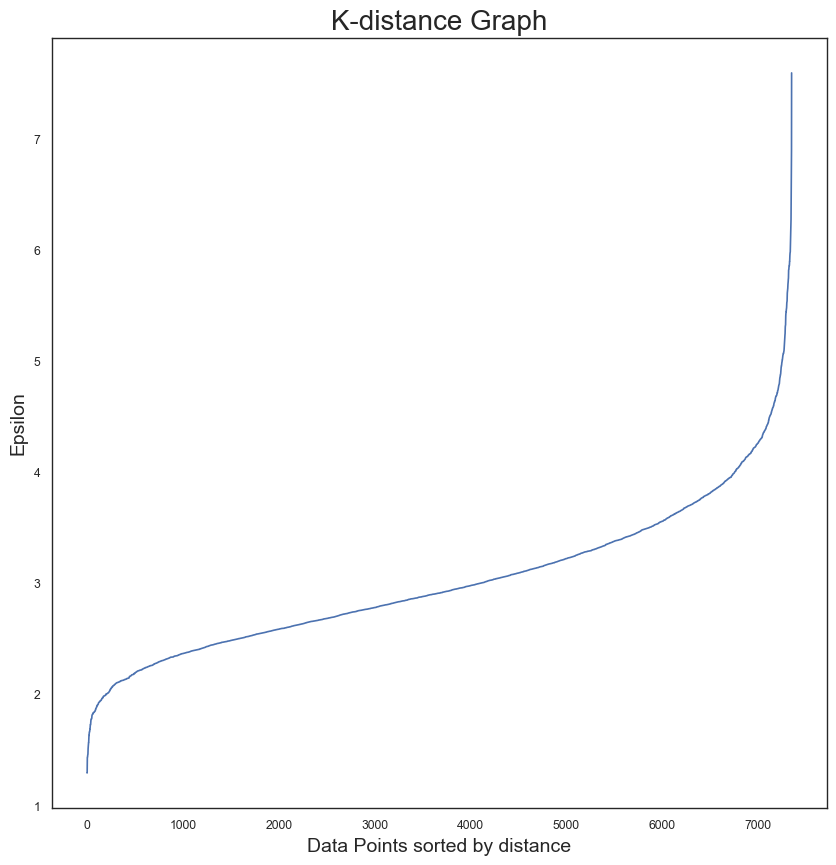

In [187]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10,10))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

In [173]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Define range of min_samples values to test
min_samples_range = range(2, 20)

# Initialize lists to store results
silhouette_scores = []

# Iterate over range of min_samples values
for min_samples in min_samples_range:
    # Initialize DBSCAN with current min_samples value
    dbscan = DBSCAN(eps=3, min_samples=min_samples)
    
    # Fit the data
    dbscan.fit(data)
    
    # Calculate the silhouette score
    silhouette_scores.append(silhouette_score(data, dbscan.labels_))

# Find the index of the max silhouette score
optimal_index = np.argmax(silhouette_scores)

# Find the optimal min_samples value
optimal_min_samples = min_samples_range[optimal_index]

print("Optimal min_samples value:", optimal_min_samples)

C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\sami0\anaconda3\lib\site-packages\sklea

Optimal min_samples value: 10


In [174]:
dbscan=DBSCAN(eps=4.5,min_samples=10)
clusters = dbscan.fit_predict(data)

C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(


In [175]:
n_clusters = len(np.unique(clusters)) - (1 if -1 in clusters else 0)
print("Estimated number of clusters:", n_clusters)

Estimated number of clusters: 3


In [176]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(data)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])
principalDf.head()

C:\Users\sami0\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(


,principal component 1,principal component 2
0,-5.520280,-0.290278
1,-5.535350,-0.082530
2,-5.474988,0.287387
3,-5.677232,0.897031
4,-5.748749,1.162952


In [177]:
finalDf = pd.concat([principalDf, train['ActivityName']], axis = 1)
finalDf.head()

,principal component 1,principal component 2,"(ActivityName,)"
0,-5.520280,-0.290278,STANDING
1,-5.535350,-0.082530,STANDING
2,-5.474988,0.287387,STANDING
3,-5.677232,0.897031,STANDING
4,-5.748749,1.162952,STANDING


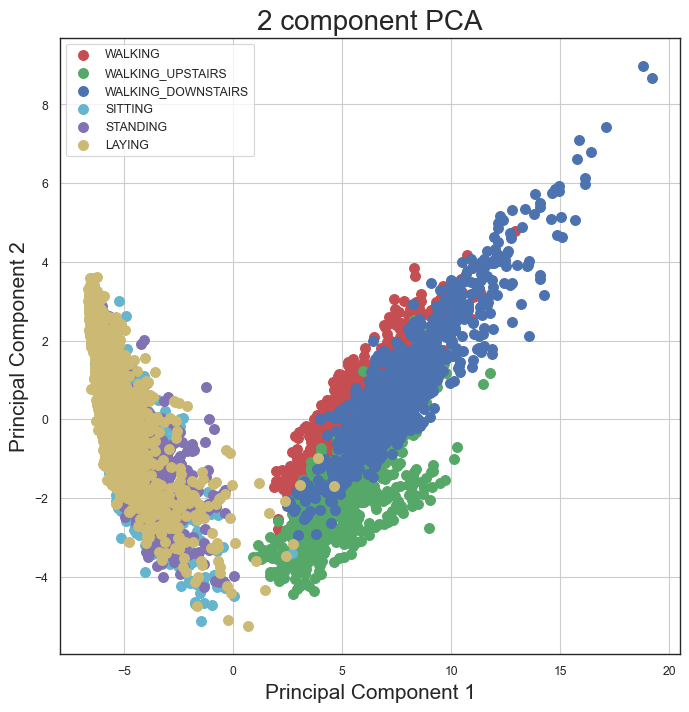

In [178]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
targets = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
cmap='rainbow'
for target, color in zip(targets,colors):
    indicesToKeep = finalDf.iloc[:, -1] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [179]:
import umap.umap_ as umap

# Perform UMAP dimension reduction
reducer = umap.UMAP()
umap_result = reducer.fit_transform(data)

# Create a new DataFrame with UMAP results
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP component 1', 'UMAP component 2'])
umap_df['ActivityName'] = train['ActivityName']

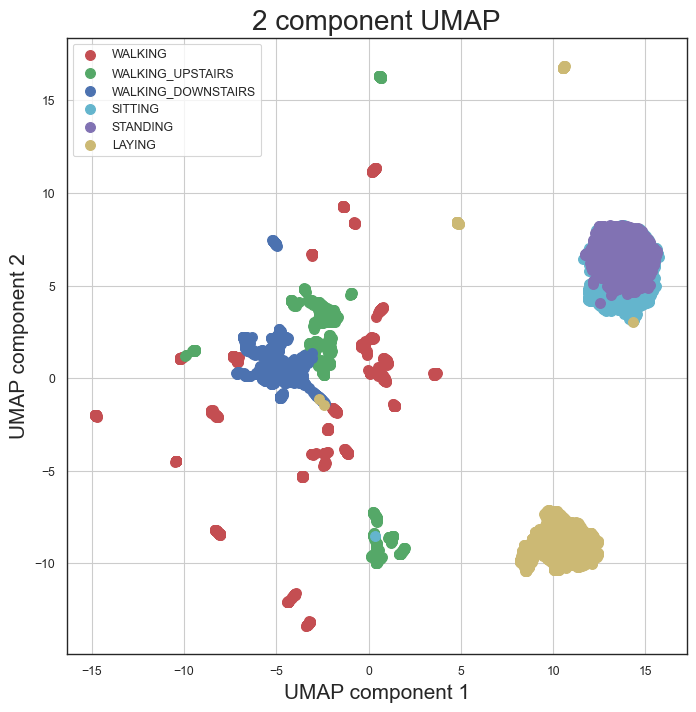

In [180]:
# Visualize the UMAP results
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('UMAP component 1', fontsize=15)
ax.set_ylabel('UMAP component 2', fontsize=15)
ax.set_title('2 component UMAP', fontsize=20)
targets = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
cmap = 'rainbow'

for target, color in zip(targets, colors):
    indicesToKeep = umap_df['ActivityName'] == target
    ax.scatter(umap_df.loc[indicesToKeep, 'UMAP component 1'],
               umap_df.loc[indicesToKeep, 'UMAP component 2'],
               c=color,
               s=50)
ax.legend(targets)
ax.grid()